# Categorical Encoding
**IT Number:** IT25300054 · **Name:** Humaid H M · **Dataset:** `weatherHistory.csv`

## 1. Why this technique is needed
Three columns in the dataset are text/categorical: `Summary`, `Precip Type`, and `Daily Summary`. None of them can be fed into a model as raw strings, and `Daily Summary` in particular is far too fragmented (dozens of near-duplicate sentences) to encode directly. This notebook picks up the dataset after Member 1's missing-value fix, simplifies the noisy text categories, and encodes everything into numeric form.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/weatherHistory.csv")
df["Precip Type"] = df["Precip Type"].fillna("none")  # from Member 1's step
print("Shape:", df.shape)

for col in ["Summary", "Precip Type", "Daily Summary"]:
    print(f"{col}: {df[col].nunique()} unique values")

Shape: (96453, 12)
Summary: 27 unique values
Precip Type: 3 unique values
Daily Summary: 214 unique values


`Precip Type` is a clean 3-category column (`rain`, `snow`, `none`) and is a good fit for **one-hot encoding** — there's no natural order between them. `Daily Summary`, on the other hand, has 200+ nearly-identical free-text sentences (e.g. "Partly cloudy throughout the day." vs. "Partly cloudy starting in the morning.") which is far too sparse to encode as-is, so it's first simplified into a handful of weather categories based on keywords, the same way it's done in the group's shared preprocessing draft.

In [2]:
print("Daily Summary unique values:", df["Daily Summary"].nunique())
df["Daily Summary"].value_counts().head(10)

Daily Summary unique values: 214


Daily Summary
Mostly cloudy throughout the day.                                  20085
Partly cloudy throughout the day.                                   9981
Partly cloudy until night.                                          6169
Partly cloudy starting in the morning.                              5184
Foggy in the morning.                                               4201
Foggy starting overnight continuing until morning.                  3576
Partly cloudy until evening.                                        3288
Mostly cloudy until night.                                          3095
Overcast throughout the day.                                        2952
Partly cloudy starting in the morning continuing until evening.     2806
Name: count, dtype: int64

In [3]:
def simplify_weather(summary):
    summary = summary.lower()
    if "rain" in summary or "drizzle" in summary:
        return "Rainy"
    elif "foggy" in summary:
        return "Foggy"
    elif "cloudy" in summary or "overcast" in summary:
        return "Cloudy"
    elif "clear" in summary:
        return "Clear"
    elif "windy" in summary or "breezy" in summary:
        return "Windy"
    else:
        return "Other"

df["Daily_Summary_Simplified"] = df["Daily Summary"].apply(simplify_weather)
print("Reduced from", df["Daily Summary"].nunique(), "to", df["Daily_Summary_Simplified"].nunique(), "categories")
print(df["Daily_Summary_Simplified"].value_counts())

Reduced from 214 to 5 categories
Daily_Summary_Simplified
Cloudy    76191
Foggy     19037
Clear       913
Rainy       240
Windy        72
Name: count, dtype: int64


`Summary` (27 categories, e.g. "Partly Cloudy", "Mostly Cloudy", "Breezy and Overcast") is kept at full resolution since it's the group's most detailed weather-condition field, but with 27 levels it's better suited to **label encoding** than one-hot, since one-hot would add 27 sparse columns for what is mostly a handful of dominant categories.

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Summary_encoded"] = le.fit_transform(df["Summary"])
print(dict(list(zip(le.classes_, range(len(le.classes_))))[:6]), "...")

df_encoded = pd.get_dummies(df, columns=["Precip Type"], prefix="Precip")
le2 = LabelEncoder()
df_encoded["Daily_Summary_Simplified_encoded"] = le2.fit_transform(df_encoded["Daily_Summary_Simplified"])
print(dict(zip(le2.classes_, range(len(le2.classes_)))))

precip_cols = [c for c in df_encoded.columns if c.startswith("Precip_")]
print("\nNew one-hot columns:", precip_cols)
df_encoded[precip_cols].sum()

{'Breezy': 0, 'Breezy and Dry': 1, 'Breezy and Foggy': 2, 'Breezy and Mostly Cloudy': 3, 'Breezy and Overcast': 4, 'Breezy and Partly Cloudy': 5} ...
{'Clear': 0, 'Cloudy': 1, 'Foggy': 2, 'Rainy': 3, 'Windy': 4}

New one-hot columns: ['Precip_none', 'Precip_rain', 'Precip_snow']


Precip_none      517
Precip_rain    85224
Precip_snow    10712
dtype: int64

In [5]:
import os
os.makedirs("../results/outputs", exist_ok=True)
df_encoded.to_csv("../results/outputs/member3_categorical_encoded.csv", index=False)
print("Saved. Final shape:", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())

Saved. Final shape: (96453, 17)
Columns: ['Formatted Date', 'Summary', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary', 'Daily_Summary_Simplified', 'Summary_encoded', 'Precip_none', 'Precip_rain', 'Precip_snow', 'Daily_Summary_Simplified_encoded']


## 2. EDA Visualization

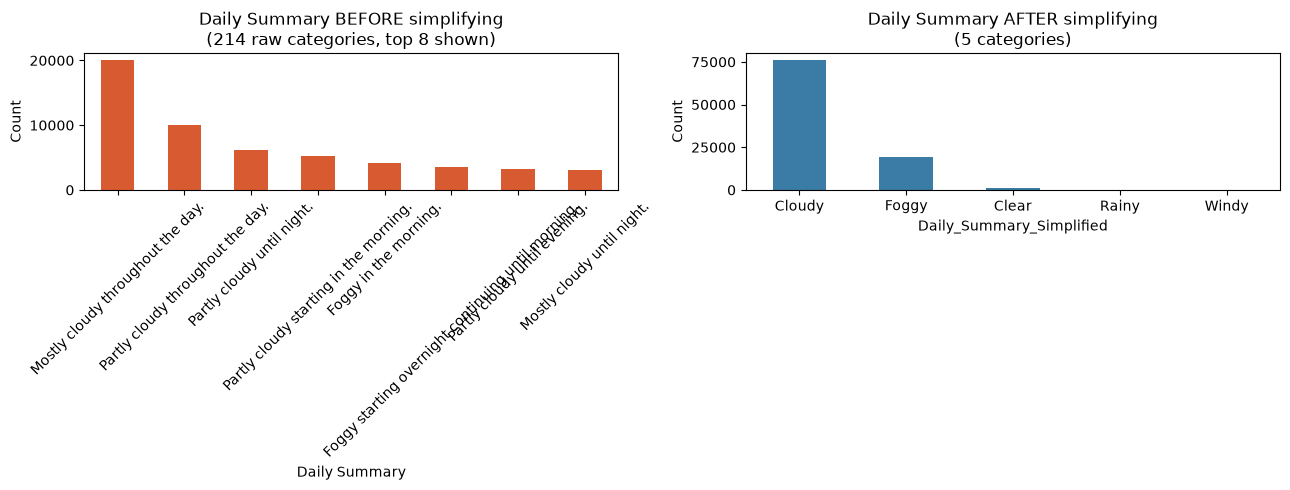

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df["Daily Summary"].value_counts().head(8).plot(kind="bar", ax=axes[0], color="#D85A30")
axes[0].set_title(f"Daily Summary BEFORE simplifying\n({df['Daily Summary'].nunique()} raw categories, top 8 shown)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

df["Daily_Summary_Simplified"].value_counts().plot(kind="bar", ax=axes[1], color="#3A7CA5")
axes[1].set_title(f"Daily Summary AFTER simplifying\n({df['Daily_Summary_Simplified'].nunique()} categories)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
import os
os.makedirs("../results/eda_visualizations", exist_ok=True)
plt.savefig("../results/eda_visualizations/member3_categorical_encoding.png", dpi=110)
plt.show()

**Interpretation:** the raw `Daily Summary` field is dominated by "Partly cloudy..." variants that only differ in wording, which is why the count for any single raw category looks small relative to the whole dataset. After simplification, **Cloudy** clearly dominates (matches the humid, overcast-prone climate implied by the broader EDA), giving a distribution that's actually usable as a categorical feature or secondary label.